In [ ]:
%load_ext autoreload
%autoreload 2

from edunn import utils
import edunn as nn
import numpy as np

# Error medio o promedio

Si bien la capa SquaredError nos permite calcular los errores de cada ejemplo, para obtener una medida del error respecto a un lote o conjunto de ejemplos, tenemos que calcular el promedio de estos errores. Como este cálculo es independiente de la función de error, podemos encapsularlo en su propia clase. Implementar el método `forward` de la clase error medio.

Nota: Muchas veces a la función de error también se la llama _loss_, para distinguirla del error promedio

In [ ]:
y = np.array([[2, -2], [-4, 4]])
y_true = np.array([[3, 3], [-5, 2]])


layer = nn.MeanError(nn.SquaredError())
E = 15.5
utils.check_same_float(E, layer.forward(y, y_true), title="mean error")

# Backward

Para avanzar más rápido, y porque contiene algún truquillo, el paso `backward` ya está implementado, pero te sugerimos pensar como lo implementarías y luego compararlo la implementación de referencia.

<details>
<summary>Ayuda:</summary>

Por si misma, esta ya es una implementación _por lotes_ (alegando a la simplicidad, los $E_i$ representan el `nn.SquaredError` del ejemplo $i$). Por definición, el error promedio se calcula como (siendo $N$ el número de ejemplos en el lote):

$$E_{\text{mean}}(E_1,E_2,...,E_N) = \frac{1}{N} \sum_{i=1}^N E_i(y_i, y'_i)$$

Para calcular $\frac{dE}{dE_i}$ (misma razón por la que se calcula $\frac{dE}{dx}$ en las capas `nn.Bias`, `nn.Linear`, etc.), así este puede ser propagado hacia atrás (a la capa `nn.SquaredError`), entonces para calculando para un error particular $E_j$:

$$
\begin{aligned}
\frac{dE}{dE_j} &= \frac{d(\frac{1}{N} \sum_{i=1}^N E_i(y_i, y'_i))}{dE_j} \\
&= \frac{1}{N} \sum_{i=1}^N \frac{dE_i(y_i, y'_i)}{dE_j} \\
&= \frac{1}{N} \frac{dE_j(y_i, y'_i)}{dE_j} = \frac{1}{N}
\end{aligned}
$$

Generalizando, es evidente que el resultado será un vector columna con todos sus elementos iguales a $\frac{1}{N}$:

$$\frac{dE}{dE_i} = (\frac{dE}{dE_{i,1}}, \frac{dE}{dE_{i,2}}, ..., \frac{dE}{dE_{i,N}})^T
= \frac{1}{N} \begin{bmatrix}
1 \\ 
1 \\ 
\vdots \\ 
1 \end{bmatrix} \in \mathbb{R}^N
$$

**Importante**: se expresa $E_i$ para representar a $E_{\text{SquaredError}}(y,y')$, únicamente para que se respete el nombre de las variables con respecto a la implementación en la librería.

Finalmente, el método `backward` de una capa de error **final** como lo es `nn.MeanError`, también deberá invocar al `backward` de la capa de error de ejemplos, también conocido como _loss_ (como lo puede ser `nn.SquaredError`). 

En el código a `dE_dE_i` lo llamamos `dE_dEy` (lo cual no es incorrecto, y sigue la misma lógica que el cálculo de `dE_dEy` en la capa `nn.SquaredError`, ya que es considerar la salida de tal capa como si fuese `y` en lugar de `E`) y es el parámetro que se le pasa al backward de la `sample_error_layer`.

<!-- Para calcular $\frac{dE}{dy_\text{sample}}$ conociendo $\frac{dE}{dy}$ (calculado por `nn.SquaredError`, ya que `nn.MeanError` la conoce por la manera en la que se crea tal capa de error: `nn.MeanError(nn.SquaredError())`), es evidente que éste será igual a:

$$
\begin{aligned}
\frac{dE}{dy_\text{sample}} &= \frac{d(\frac{1}{N} \sum_{i=1}^N E_i(y_i, y'_i))}{dy_\text{sample}} \\
&= \frac{1}{N} \sum_{i=1}^N \frac{d(E_i(y_i, y'_i))}{dy_\text{sample}} \\
&= \frac{dE_i}{dy}
\end{aligned}
$$

Tener en cuenta que **sample** se refiere a TODA la muestra. -->

### Conclusiones finales en el desarrollo de capas backward en el código

En el `backward` de la capa actual se recibe `dE_dy` que es calculada por la capa siguiente, y ésta es la derivada del error (última capa) con respecto a la salida de la capa actual. En el método `backward` de la capa actual hay que calcular `dE_dx` que es la derivada del error (última capa) con respecto a la entrada de la capa actual. Esto luego será propagado hacia atrás, haciendo que para la capa de anterior `dE_dx` se pase como parámetro a su `backward`, así haciendo que sea tomado por la capa anterior como el parámetro `dE_dy`.

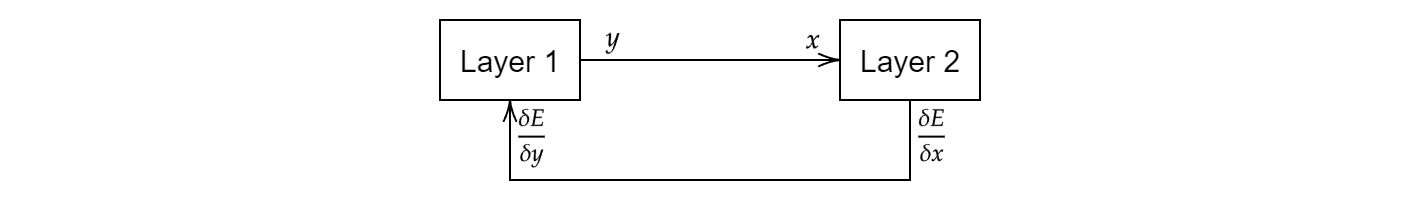

<!-- 
\tikzset{every picture/.style={line width=0.75pt}} %set default line width to 0.75pt        

\begin{tikzpicture}[x=0.75pt,y=0.75pt,yscale=-1,xscale=1]
%uncomment if require: \path (0,101); %set diagram left start at 0, and has height of 101

%Shape: Rectangle [id:dp3688185948432916] 
\draw   (220,10) -- (290,10) -- (290,50) -- (220,50) -- cycle ;

%Shape: Rectangle [id:dp871137633865797] 
\draw   (420,10) -- (490,10) -- (490,50) -- (420,50) -- cycle ;

%Straight Lines [id:da39878591954456] 
\draw    (290,30) -- (418,30) ;
\draw [shift={(420,30)}, rotate = 180] [color={rgb, 255:red, 0; green, 0; blue, 0 }  ][line width=0.75]    (10.93,-3.29) .. controls (6.95,-1.4) and (3.31,-0.3) .. (0,0) .. controls (3.31,0.3) and (6.95,1.4) .. (10.93,3.29)   ;
%Straight Lines [id:da01966990131918278] 
\draw    (455,50) -- (455,90) -- (255,90) -- (255,52) ;
\draw [shift={(255,50)}, rotate = 90] [color={rgb, 255:red, 0; green, 0; blue, 0 }  ][line width=0.75]    (10.93,-3.29) .. controls (6.95,-1.4) and (3.31,-0.3) .. (0,0) .. controls (3.31,0.3) and (6.95,1.4) .. (10.93,3.29)   ;


% Text Node
\draw (229,22) node [anchor=north west][inner sep=0.75pt]   [align=left] {Layer 1};
% Text Node
\draw (429,22) node [anchor=north west][inner sep=0.75pt]   [align=left] {Layer 2};
% Text Node
\draw (302,12.9) node [anchor=north west][inner sep=0.75pt]  [font=\footnotesize]  {$y$};
% Text Node
\draw (402,13.9) node [anchor=north west][inner sep=0.75pt]  [font=\footnotesize]  {$x$};
% Text Node
\draw (457,53.4) node [anchor=north west][inner sep=0.75pt]  [font=\scriptsize]  {$\frac{dE}{dx}$};
% Text Node
\draw (257,53.4) node [anchor=north west][inner sep=0.75pt]  [font=\scriptsize]  {$\frac{dE}{dy}$};


\end{tikzpicture}
 -->

 </details>